# EE 220 - Homework 1 - Supplement 1
## Introduction to Monte Carlo Simulation
In this homework supplement, we will examine the effects of resistor and capacitor variations. Please copy this notebook into your Google drive, and run it from there.

You do not need to submit anything for this supplementary homework, but please make sure you understand the concepts.


In [1]:
# @title Install schematic libraries

!pip install schemdraw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.5/152.5 kB 3.0 MB/s eta 0:00:00


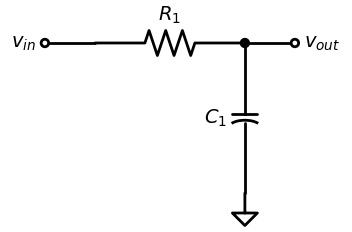

In [2]:
# @title Draw the simple RC low-pass filter schematic

import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Dot(open=True).label('$v_{in}$', loc='left')
    elm.Line().right().length(1)
    R1 = elm.Resistor().label('$R_1$')
    d.push()
    C1 = elm.Capacitor2().down().label('$C_1$')
    elm.GroundSignal()
    d.pop()
    elm.Dot()
    elm.Line().right().length(1)
    elm.Dot(open=True).label('$v_{out}$', loc='right')

In [3]:
# @title Install Conda

import os

CONDA_PREFIX = os.environ.get('CONDA_PREFIX', None)

if not CONDA_PREFIX:
  !python -m pip install condacolab
  import condacolab
  condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:17
🔁 Restarting kernel...


# Note:
If the kernel restarts, please re-run the cells below. Select the cell below, then from the menu, click on '**Runtime**' --> '**Run cell and below**'

In [1]:
# @title Setup Conda packages

%%writefile environment.yml
channels:
  - litex-hub
dependencies:
  - ngspice

Writing environment.yml


In [2]:
# @title Install Conda packages

!mamba env update -n base -f environment.yml

[+] 0.0s
[+] 0.1s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.2s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.3s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.4s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.5s
litex-hub/linux-64..  ⣾  [+] 0.6s
litex-hub/linux-64..  ⣾  [+] 0.7s
litex-hub/linux-64..  ⣾  [+] 0.8s
litex-hub/linux-64..  ⣾  [+] 0.0s
[+] 0.1s
[+] 0.2s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.3s
conda-forge/linux-64   2%
conda-forge/noarch     1%
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.4s
conda-forge/linux-64   2%
conda-forge/noarch     1%
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.5s
conda-forge/linux-64   4%
conda-forge/noarch     3%
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.6s
conda-forge/linux-64   6%
conda-forge/noarch     7%
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.7s
conda-forge/linux-64   7%
co

In [3]:
# @title Configure NGSPICE
%%writefile .spiceinit
* ngspice initialization for sky130
* assert BSIM compatibility mode with "nf" vs. "W"
set ngbehavior=hsa
* "nomodcheck" speeds up loading time
set ng_nomodcheck
set wr_singlescale

Writing .spiceinit


In [4]:
# @title Create the circuit netlist
%%writefile netlist.spice
* Semiconductor resistor characteristics

.options savecurrents seed=random

* Polysilicon resistor models
.model rpoly_n R rsh=100 tc1=-800u tnom=27C
.model rpoly_p R rsh=180 tc1=200u tnom=27C


* MOM capacitor model
.model cmom C cj=50m tc1=30u tnom=27C
.model cmsub C cj=30m tc1=25u tnom=27C

* Capacitor with bottom-plate parasitic capacitance
.subckt cm  top bottom sub  w=1000u l=2000u
C1		top bottom	cmom w={w} l={l}
Csub	bottom sub	cmsub w={w} l={l}
.ends

R1		in out		rpoly_n w=2u l=20u
X1		out 0 0		cm w=1000u l=2000u

Vs		in 0		dc 0 ac 1

.control

let mc_runs = 1000
let run = 1

define gauss(nom, var) (nom + nom*var * sgauss(0))

dowhile run <= mc_runs

	* mismatch
	alter @R1[l] = gauss(20u, 0.01)
	alter @R1[w] = gauss(2u, 0.01)

	let l1 = gauss(2000u, 0.01)
	alter @c.x1.c1[l] = l1
	alter @c.x1.csub[l] = l1

	let l2 = gauss(1000u, 0.01)
	alter @c.x1.c1[w] = l2
	alter @c.x1.csub[w] = l2

	* process
	altermod @rpoly_n[rsh] = gauss(100, 0.01)
	altermod @cmom[cj] = gauss(50m, 0.01)
	altermod @cmsub[cj] = gauss(30m, 0.01)

	ac dec 1000 10 10k
	echo {$run}
	meas ac fc WHEN vdb(out)=-3 FALL=1

	let R1 = @r1[r]
	let C1 = @c.x1.c1[cap]
	set run = "$&run"

	echo {$run} {$&R1} {$&C1} {$&fc} >> output_mc.dat

	let run = run + 1
end

.endc

.end

Writing netlist.spice


In [5]:
# @title Run NGSPICE
!rm output_mc.dat
!ngspice -b netlist.spice

Streaming output truncated to the last 5000 lines.
fc                  =  1.564617e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
167
fc                  =  1.591835e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
168
fc                  =  1.585993e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
169
fc                  =  1.624444e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
170
fc                  =  1.607597e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
171
fc                  =  1.589678e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
172
fc                  =  1.646274e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 3001
173
fc                  =  1.607204e+03
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


N

In [6]:
# @title Read in SPICE transient simulation data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_mc = pd.read_csv("output_mc.dat", sep='\\s+', header=None)
df_mc.columns = ["runs", "R1", "C1", "fc"]
df_mc

,runs,R1,C1,fc
0,1,988.070,1.008190e-07,1593.90
1,2,994.043,1.014410e-07,1574.61
2,3,1000.890,9.757430e-08,1625.80
3,4,1050.110,1.018540e-07,1484.49
4,5,974.601,9.704430e-08,1678.77
...,...,...,...,...
995,996,981.997,1.001920e-07,1613.79
996,997,999.915,9.971160e-08,1592.50
997,998,984.581,1.019580e-07,1581.68
998,999,991.692,9.823730e-08,1629.80


In [7]:
# @title Calculate the means and variances

R1_mean = np.mean(df_mc.R1)
R1_var = np.var(df_mc.R1)

C1_mean = np.mean(df_mc.C1)
C1_var = np.var(df_mc.C1)

fc_mean = np.mean(df_mc.fc)
fc_var = np.var(df_mc.fc)

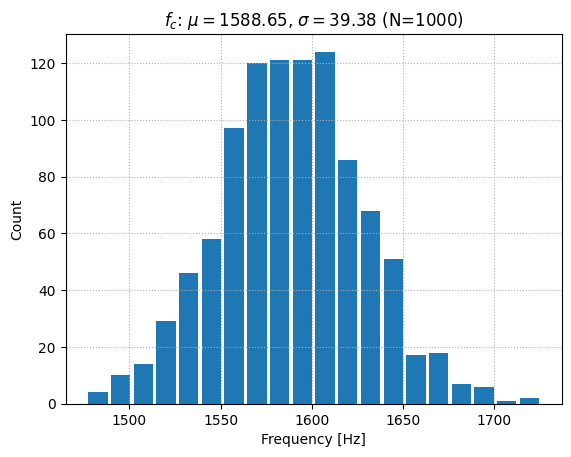

In [8]:
# @title Plot the historgram of the RC low-pass filter corner frequency

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.hist(x=df_mc.fc, bins=20, rwidth=0.85)

plt.title(r'$f_c$: $\mu=${:.2f}, $\sigma=${:.2f} (N={})'.format( \
            fc_mean, np.sqrt(fc_var), len(df_mc.runs)))

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Count")


plt.grid(linestyle='dotted')
plt.show()

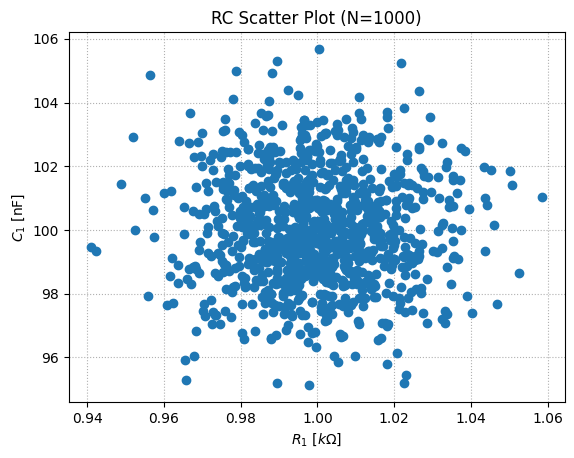

In [9]:
# @title Scatter plot the R and C values

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([R/1e3 for R in df_mc.R1], [C/1e-9 for C in df_mc.C1], 'o')

plt.title(r'RC Scatter Plot (N={})'.format(len(df_mc.runs)))
plt.xlabel(r"$R_1$ [$k\Omega$]")
plt.ylabel(r"$C_1$ [nF]")

plt.grid(linestyle='dotted')
plt.show()